# **LangGraph Messages**

In [1]:
from dotenv import load_dotenv
import os
load_dotenv()
from pydantic import BaseModel
from typing import List
from langgraph.graph import StateGraph,START,END
from langchain.messages import SystemMessage,HumanMessage,AIMessage
from langchain_groq import ChatGroq
from pprint import pprint

if os.environ['GROQ_API_KEY']:
    print("GROQ_API_KEY is set.")
else:
    raise ValueError("GROQ_API_KEY is not set. Please set it in your .env file.")

d:\GEN-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GROQ_API_KEY is set.


In [2]:
llm = ChatGroq(model='meta-llama/llama-4-scout-17b-16e-instruct', temperature=0.5)
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002CC7DAB8AD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002CC7DAB9550>, model_name='meta-llama/llama-4-scout-17b-16e-instruct', temperature=0.5, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

## **Storing entire history using Pydantic**

In [3]:
class Message(BaseModel):
    
    messages: List #type: ignore


In [4]:
def create_message(state: Message)->Message:
    result = llm.invoke(state.messages).content #type: ignore
    state.messages.append(AIMessage(content=result)) #type: ignore
    return state

def curate_message(state: Message)-> Message:
    
    curated_content = llm.invoke(f"My content is {state.messages}, Curate the content for me with in 50 words.").content #type: ignore
    state.messages.append(AIMessage(content=curated_content)) #type: ignore
    return state


In [5]:
graph = StateGraph(Message)

graph.add_node('create_message',create_message) #type: ignore
graph.add_node('curate_message',curate_message) #type: ignore

graph.add_edge(START,'create_message')
graph.add_edge('create_message','curate_message')
graph.add_edge('curate_message',END)

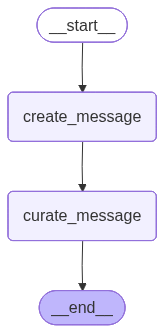

In [6]:
Pydantic_graph = graph.compile() #type: ignore
Pydantic_graph

In [7]:
result = Pydantic_graph.invoke({"messages": [SystemMessage(content="You are a helpful assistant that helps to create a graph of states and transitions based on user input. The graph should start with a START state and end with an END state. Each state should have a unique name and can have multiple transitions to other states. The transitions should be based on the user's input and should be clearly defined. The graph should be represented in a format that can be easily visualized and understood."),HumanMessage(content="Tell me about Python?")]})  # type: ignore
pprint(result)

{'messages': [SystemMessage(content="You are a helpful assistant that helps to create a graph of states and transitions based on user input. The graph should start with a START state and end with an END state. Each state should have a unique name and can have multiple transitions to other states. The transitions should be based on the user's input and should be clearly defined. The graph should be represented in a format that can be easily visualized and understood.", additional_kwargs={}, response_metadata={}),
              HumanMessage(content='Tell me about Python?', additional_kwargs={}, response_metadata={}),
              AIMessage(content='**Introduction to Python**\n==========================\n\nPython is a high-level, interpreted programming language that is widely used for various purposes such as web development, scientific computing, data analysis, artificial intelligence, and more.\n\n**Key Features of Python**\n---------------------------\n\n*   **Easy to Learn**: Python